# The utilization trap: why the last 10% of capacity is the most expensive

An engineer sizing a service reasons linearly: *"the server can do 100 req/s, I need 80, so I'm
fine with 20% headroom."* Queueing theory says otherwise. As utilization ρ approaches 1, the
waiting time doesn't grow linearly — it **explodes** like `1/(1-ρ)`. Running a system at 90%
instead of 80% doesn't cost you a little; it **more than doubles** the delay.

The flip side is a second non-obvious lesson: **pooling**. One big server pool is far more
efficient than many small ones at the *same* utilization — the "economies of scale" of queues.

We compute both with the library's exact M/M/c calculator.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from most_queue.theory.fifo.mmnr import MMnrCalc

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "font.size": 11})
MU = 1.0  # service rate per server

def mean_sojourn(n_servers, rho):
    # exact M/M/n mean sojourn at utilization rho (per server)
    r = 800 if n_servers == 1 else 90  # queue truncation (kept modest to avoid Erlang overflow)
    c = MMnrCalc(n=n_servers, r=r)
    c.set_sources(l=rho * n_servers * MU)
    c.set_servers(mu=MU)
    return c.run().v[0]


## 1. The hockey stick

For an M/M/1 queue the mean response time is `E[T] = 1 / (μ(1-ρ))`. Plotted against utilization,
it is flat and comfortable up to ~70%, then shoots up.

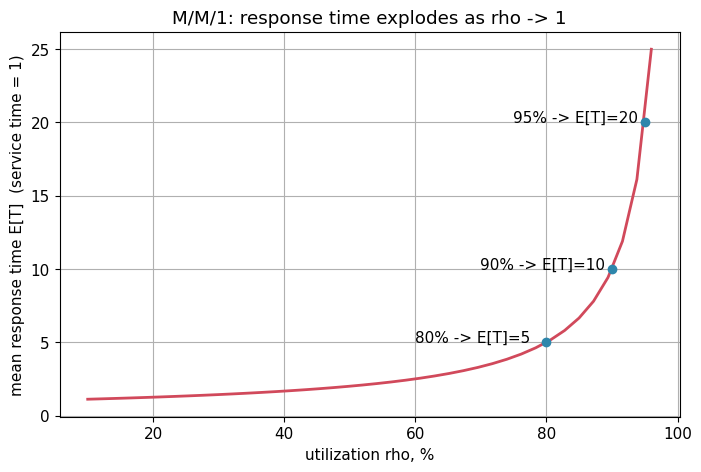

raising utilization 50% -> 80%:  E[T] x2.50
raising utilization 80% -> 90%:  E[T] x2.00
raising utilization 90% -> 95%:  E[T] x2.00


In [2]:
rhos = np.linspace(0.1, 0.96, 40)
et = [mean_sojourn(1, r) for r in rhos]

fig, ax = plt.subplots()
ax.plot(rhos * 100, et, color="#d1495b", lw=2)
for r in [0.8, 0.9, 0.95]:
    ax.scatter([r * 100], [mean_sojourn(1, r)], zorder=5, color="#2e86ab")
    ax.annotate(f"{r*100:.0f}% -> E[T]={mean_sojourn(1, r):.0f}",
                (r * 100, mean_sojourn(1, r)), textcoords="offset points", xytext=(-95, 0))
ax.set_xlabel("utilization rho, %")
ax.set_ylabel("mean response time E[T]  (service time = 1)")
ax.set_title("M/M/1: response time explodes as rho -> 1")
plt.show()

for a, b in [(0.5, 0.8), (0.8, 0.9), (0.9, 0.95)]:
    print(f"raising utilization {a:.0%} -> {b:.0%}:  E[T] x{mean_sojourn(1, b)/mean_sojourn(1, a):.2f}")


**The insight.** Going from 50% to 80% barely hurts, but **80% -> 90% doubles** the wait and
**90% -> 95% doubles it again**. The "headroom" you think you have near full load is an illusion —
a small demand spike at 90% utilization sends latency through the roof. Capacity plans should be
made against `1/(1-ρ)`, not against raw throughput.

## 2. Economies of scale: pool your servers

Compare systems at the **same** utilization (80%) but with different numbers of servers. Naively
they are "equally loaded", so you'd expect equal performance. In fact the mean **waiting** time
collapses as the pool grows.

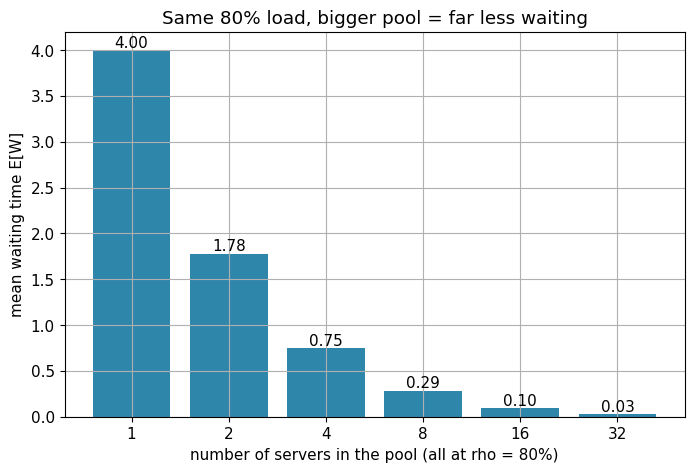

two separate M/M/1 (each rho=0.8): E[T] = 5.000
one pooled M/M/2 (same total load): E[T] = 2.778
=> merging the two queues cuts the wait by 2.3x, for free


In [3]:
ns = [1, 2, 4, 8, 16, 32]
wait = [mean_sojourn(n, 0.8) - 1.0 / MU for n in ns]

fig, ax = plt.subplots()
bars = ax.bar([str(n) for n in ns], wait, color="#2e86ab")
ax.bar_label(bars, fmt="%.2f")
ax.set_xlabel("number of servers in the pool (all at rho = 80%)")
ax.set_ylabel("mean waiting time E[W]")
ax.set_title("Same 80% load, bigger pool = far less waiting")
plt.show()

# pooling: two separate M/M/1 vs one M/M/2 handling the same total traffic
sep = mean_sojourn(1, 0.8)
pooled = mean_sojourn(2, 0.8)
print(f"two separate M/M/1 (each rho=0.8): E[T] = {sep:.3f}")
print(f"one pooled M/M/2 (same total load): E[T] = {pooled:.3f}")
print(f"=> merging the two queues cuts the wait by {(sep-1)/(pooled-1):.1f}x, for free")


**The insight.** At the *same* utilization, an M/M/16 pool makes customers wait ~40x less than
an M/M/1. Splitting traffic across many small independent queues (per-instance load balancing,
sharded workers, "one queue per server") wastes this effect: a server can sit idle while a job
waits in another queue. **Combine queues** (shared work queue, join-the-shortest-queue,
central dispatch) and you get dramatically lower latency at no extra hardware.

## Takeaways for engineers

- Plan capacity against `1/(1-ρ)`: **the last 10% of utilization is the most expensive**. Target
  ~70-80%, not 95%, unless you can tolerate huge latency variance.
- **Pool servers.** One shared queue of `c` servers beats `c` separate single-server queues at the
  same load — the bigger the pool, the bigger the win.
- These effects are invisible to a purely throughput-based capacity model; they only show up when
  you model the queue.